# ONERA 468 CRM Challenge $\rho$ : Starting Kit

This notebook shows how to load the data, explore the database structure, train the KNN baseline model, and prepare a submission.

---
## 0. Dataset overview

### General structure

The database consists of **468 CFD simulations** (ONERA CRM, Wind Tunnel configuration), covering the aerodynamic characteristics listed in the table below.

| Paramètre | Symbole | Valeurs |
|-----------|---------|----------|
| Mach number | $M_\infty$ | 0.30, 0.50, 0.70, 0.75, 0.80, 0.82, 0.84, 0.85, 0.86, 0.88, 0.90, 0.93, 0.96 |
| Angle of attack | AoA | −15°, −10°, −5°, −4°, −3°, −2°, 0°, 2°, 3°, 4°, 5°, 10° (12 valeurs) |
| Stagnation pressure | $P_i$ | $1\times10^5$, $2\times10^5$, $4\times10^5$ Pa |

Each simulation covers **np = 260,774 skin points** (fuselage surface + wing + nacelle + pylon), caracterized by:
- their Cartesian coordinates $(x, y, z)$
- their outward normal vector $(n_x, n_y, n_z)$
- the three flow condition variables $(M_\infty, \text{AoA}, P_i)$

The full X matrix (train + test merged) has shape **(np × nf, 9) = (468 * 260 774, 9)**.

### Train / test split

The split is performed **along the Mach axis**, to assess the model's ability to generalise to unseen Mach values :

| Ensemble | Mach numbers | Nb conditions |
|----------|-------------|---------------|
| **Train** | 0.50, 0.70, 0.75, 0.80, 0.82, 0.84, 0.85, 0.86, 0.88 | **324** |
| **Test Phase 1** | 0.90, 0.93 | **72** |
| **Test Phase 2** | 0.30, 0.96 | **72** |

### Array sizes

```
X_train : (324 × 260 774, 9)
y_train : (324 × 260 774, 1)  
X_test_phase_1  : (144 × 260 774, 9) 
X_test_phase_2  : (144 × 260 774, 9)  
```

### Confidence weights

Each simulation is assigned a confidence weight :
- **1.0** for well-converged simulations ($|\text{AoA}| < 10°$)
- **0.5** for low-confidence simulations ($|\text{AoA}| \geq 10°$)

These weights are used when computing the official evaluation metric.


<!-- 
# ### Target variable

# The target is the **volumetric density** $\rho$ (normalisée par la densité de référence), evaluated on the aircraft skin.
# #  Values typically range between **0.74** and **1.05** depending on the flow conditions.

# ### Evaluation metric

# The official score combines two metrics :
# $$\text{score} = 5 \cdot R^2 + 5 \cdot (1 - \text{wrMAE})$$
# where $\text{wrMAE}$ is the worst-case (maximum over conditions) weighted relative MAE. A perfect score equals **10**. -->

---
## 1. Loading the data

In [ ]:
import numpy as np

# input data to be downloaded through the Files section on Codabench -> Get Started
DATA_DIR = '../../feedback_phase2/input_data/'

print('Loading X_train...')
X_train = np.load(DATA_DIR + 'train_data.npy')
y_train = np.load(DATA_DIR + 'train_labels.npy')[:, 0]
y_test = np.load('../../feedback_phase2/ref/' + 'test_labels.npy')[:, 0]

X_test = np.load(DATA_DIR + 'test_data.npy')


print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}')

Loading X_train...
X_train : (84490776, 9)
y_train : (84490776,)


In [10]:
X_train = np.vstack((X_train, X_test))
y_train = np.vstack((y_train, y_test))

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 84490776 and the array at index 1 has size 18775728

In [2]:
COL_MINF, COL_AOA, COL_PI = 6, 7, 8
nwallp  = 260774
epsilon = 1.e-6

train_conds = X_train[::nwallp, COL_MINF:COL_PI+1]

mach_train, counts_train = np.unique(train_conds[:, 0], return_counts=True)

print(f'{"Mach":>6}  {"Set":<8}  {"Simulations":>11}')
print('-' * 30)
for m, c in zip(mach_train, counts_train):
    print(f'{m:>6.2f}  {"train":<8}  {c:>11}')

  Mach  Set       Simulations
------------------------------
  0.50  train              36
  0.70  train              36
  0.75  train              36
  0.80  train              36
  0.82  train              36
  0.84  train              36
  0.85  train              36
  0.86  train              36
  0.88  train              36


---
## 2. Training the KNN baseline model

The baseline model is a **k-nearest neighbours** regressor (`k=5`) applied on all 9 columns of X.

Depending on the model architecture, X can be used in two ways:
- **Pointwise regressor**: Consider the rows independent, even the ones that belonge to the same simulation.
- **Full-field regressor** Consider the simulations as non divisible entities, in this case only the 3 condition columns `(Minf, AoA, Pi)` are needed, the geometry is hidden in the ordering of the rows. This reduces X to shape `[nf, 3]`.

### 2.1 KNN baseline reference implementation

To understand what `model.py` does, here is a minimal equivalent implementation:

In [3]:
# Metrics functions
def compute_R2(y, yhat, confidence_pointwise):
    """ Weighted R^2 score. """
    ymean = np.mean(y)
    SSE   = np.sum(confidence_pointwise * (y - yhat) ** 2)
    SSD   = np.sum(confidence_pointwise * (y - ymean) ** 2)
    return float(1.0 - SSE / SSD)


def compute_wrMAE(y, yhat, confidence_per_case):
    """ Worst-case relative MAE on high-confidence conditions only. """
    ncasetest   = len(confidence_per_case)
    relMAE_list = []
    idx_list    = []

    for l in range(ncasetest):
        if confidence_per_case[l] < 1.0:
            continue
        ycase    = y   [l * nwallp:(l + 1) * nwallp]
        yhatcase = yhat[l * nwallp:(l + 1) * nwallp]
        diff     = np.abs(ycase - yhatcase)
        relMAE_list.append(np.mean(diff) / np.mean(np.abs(ycase)))
        idx_list.append(l)

    relMAE_arr   = np.array(relMAE_list)
    iworst_local = int(np.argmax(relMAE_arr))
    return idx_list[iworst_local], float(relMAE_arr[iworst_local])

def compute_rRMSE(y, yhat):
    """ Root Relative RMSE: RMSE normalised by mean(|y|). """
    rmse = np.sqrt(np.mean((y - yhat) ** 2))
    return float(rmse / np.mean(np.abs(y)))


def compute_nRMSE(y, yhat):
    """ Normalised RMSE: RMSE normalised by (max - min) of y. """
    rmse  = np.sqrt(np.mean((y - yhat) ** 2))
    yrange = np.max(y) - np.min(y)
    return float(rmse / yrange)

In [4]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

COL_MINF, COL_AOA, COL_PI = 6, 7, 8
n_train = X_train.shape[0] // nwallp

train_conds = X_train[::nwallp, COL_MINF:COL_PI+1]
train_weights = np.where(np.abs(train_conds[:, 1]) < 10.0, 1.0, 0.5)
mach_values = np.unique(train_conds[:, 0])

y_cv_pred = np.zeros_like(y_train)
fold_results = []

print(f'Leave-two-consecutive-Machs-out cross-validation ({len(mach_values) - 1} folds)')
print(f'{"Mach pair":>12}  {"R2":>8}  {"wrMAE":>8}  {"rRMSE":>8}  {"nRMSE":>8}  {"score":>8}')
print('-' * 62)

y_all = y_train.reshape(n_train, nwallp)

for i in range(len(mach_values) - 1):
    mach_pair = (mach_values[i], mach_values[i + 1])

    val_sim_idx = np.where(
        (np.abs(train_conds[:, 0] - mach_pair[0]) < epsilon) |
        (np.abs(train_conds[:, 0] - mach_pair[1]) < epsilon)
    )[0]
    train_sim_idx = np.where(
        (np.abs(train_conds[:, 0] - mach_pair[0]) >= epsilon) &
        (np.abs(train_conds[:, 0] - mach_pair[1]) >= epsilon)
    )[0]

    scaler = StandardScaler()
    fold_train_scaled = scaler.fit_transform(train_conds[train_sim_idx])
    fold_val_scaled   = scaler.transform(train_conds[val_sim_idx])

    knn = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
    knn.fit(fold_train_scaled, y_all[train_sim_idx])
    y_fold_pred = knn.predict(fold_val_scaled)

    for local_i, sim_i in enumerate(val_sim_idx):
        start = sim_i * nwallp
        y_cv_pred[start:start + nwallp] = y_fold_pred[local_i]

    fold_weights_pw = np.repeat(train_weights[val_sim_idx], nwallp)
    y_val_flat      = y_all[val_sim_idx].reshape(-1)
    y_pred_flat     = y_fold_pred.reshape(-1)

    fold_R2 = compute_R2(y_val_flat, y_pred_flat, fold_weights_pw)

    fold_weights_sim = train_weights[val_sim_idx]
    relMAE_list = []
    for k in range(len(val_sim_idx)):
        if fold_weights_sim[k] < 1.0:
            continue
        yc    = y_val_flat [k * nwallp:(k + 1) * nwallp]
        yhatc = y_pred_flat[k * nwallp:(k + 1) * nwallp]
        relMAE_list.append(np.mean(np.abs(yc - yhatc)) / np.mean(np.abs(yc)))
    fold_wrMAE = float(np.max(relMAE_list)) if relMAE_list else float('nan')
    fold_score = 5.0 * fold_R2 + 5.0 * (1.0 - fold_wrMAE)

    fold_rRMSE = compute_rRMSE(y_val_flat, y_pred_flat)
    fold_nRMSE = compute_nRMSE(y_val_flat, y_pred_flat)

    fold_results.append({
        'mach':  f'{mach_pair[0]:.2f}+{mach_pair[1]:.2f}',
        'R2':    fold_R2,
        'wrMAE': fold_wrMAE,
        'score': fold_score,
        'rRMSE': fold_rRMSE,
        'nRMSE': fold_nRMSE,
    })
    print(f'{mach_pair[0]:.2f}+{mach_pair[1]:.2f}  {fold_R2:>8.4f}  {fold_wrMAE:>8.4f}  {fold_rRMSE:>8.4f}  {fold_nRMSE:>8.4f}  {fold_score:>8.4f}')

print(f'y_cv_pred shape : {y_cv_pred.shape}')

Leave-two-consecutive-Machs-out cross-validation (8 folds)
   Mach pair        R2     wrMAE     rRMSE     nRMSE     score
--------------------------------------------------------------
0.50+0.70    0.4982    0.0963    0.0781    0.0100    7.0096
0.70+0.75    0.8520    0.0649    0.0560    0.0072    8.9357
0.75+0.80    0.9585    0.0364    0.0344    0.0197    9.6103
0.80+0.82    0.9571    0.0386    0.0376    0.0110    9.5922
0.82+0.84    0.9637    0.0365    0.0360    0.0105    9.6363
0.84+0.85    0.9702    0.0316    0.0338    0.0030    9.6929
0.85+0.86    0.9713    0.0380    0.0345    0.0031    9.6666
0.86+0.88    0.9357    0.0763    0.0543    0.0332    9.2967
y_cv_pred shape : (84490776,)


---
## 3. Computing metrics

In [ ]:
import scipy.stats as stats

R2_vals    = np.array([r['R2']    for r in fold_results])
wrMAE_vals = np.array([r['wrMAE'] for r in fold_results])
score_vals = np.array([r['score'] for r in fold_results])

def mean_ci(arr, confidence=0.95):
    n   = len(arr)
    m   = np.mean(arr)
    sem = stats.sem(arr)
    h   = sem * stats.t.ppf((1 + confidence) / 2.0, df=n - 1)
    return m, h
fold_train_scaled
R2_mean,    R2_ci    = mean_ci(R2_vals)
wrMAE_mean, wrMAE_ci = mean_ci(wrMAE_vals)
score_mean, score_ci = mean_ci(score_vals)

confidence_pointwise = np.repeat(train_weights, nwallp)
global_R2            = compute_R2(y_train, y_cv_pred, confidence_pointwise)
iworst, global_wrMAE = compute_wrMAE(y_train, y_cv_pred, train_weights)
global_score         = 5.0 * global_R2 + 5.0 * (1.0 - global_wrMAE)

rRMSE_vals = np.array([r['rRMSE'] for r in fold_results])
nRMSE_vals = np.array([r['nRMSE'] for r in fold_results])

rRMSE_mean, rRMSE_ci = mean_ci(rRMSE_vals)
nRMSE_mean, nRMSE_ci = mean_ci(nRMSE_vals)

global_rRMSE = compute_rRMSE(y_train, y_cv_pred)
global_nRMSE = compute_nRMSE(y_train, y_cv_pred)


print('Cross-validation summary (95% CI over folds)')
print(f'  rRMSE : {rRMSE_mean:.4f}  ± {rRMSE_ci:.4f}')
print(f'  nRMSE : {nRMSE_mean:.4f}  ± {nRMSE_ci:.4f}')
print(f'  R2    : {R2_mean:.4f}  ± {R2_ci:.4f}')
print(f'  wrMAE : {wrMAE_mean:.4f}  ± {wrMAE_ci:.4f}')
print(f'  score : {score_mean:.4f}  ± {score_ci:.4f}')
print()
print('Global (pooled) metrics')
print(f'  rRMSE : {global_rRMSE:.4f}')
print(f'  nRMSE : {global_nRMSE:.4f}')
print(f'  R2    : {global_R2:.4f}')
print(f'  wrMAE : {global_wrMAE:.4f}  (worst condition index: {iworst})')
print(f'  score : {global_score:.4f}  (max = 10.0)')

iworst_global = iworst
wrMAE_global  = global_wrMAE


Cross-validation summary (95% CI over folds)
  rRMSE : 0.0456  ± 0.0134
  nRMSE : 0.0122  ± 0.0083
  R2    : 0.8883  ± 0.1358
  wrMAE : 0.0523  ± 0.0200
  score : 9.1801  ± 0.7641

Global (pooled) metrics
  rRMSE : 0.0545
  nRMSE : 0.0050
  R2    : 0.9143
  wrMAE : 0.0963  (worst condition index: 2)
  score : 9.0900  (max = 10.0)


---
## 4. Visualising the aircraft

We visualise the density field $\rho$ on the aircraft surface for the worst condition computed above.

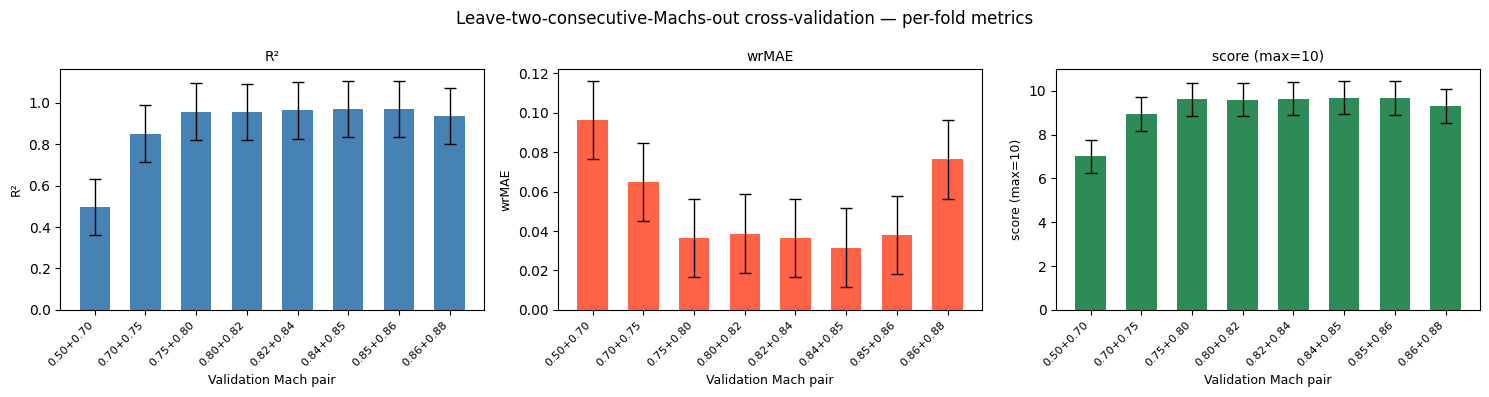

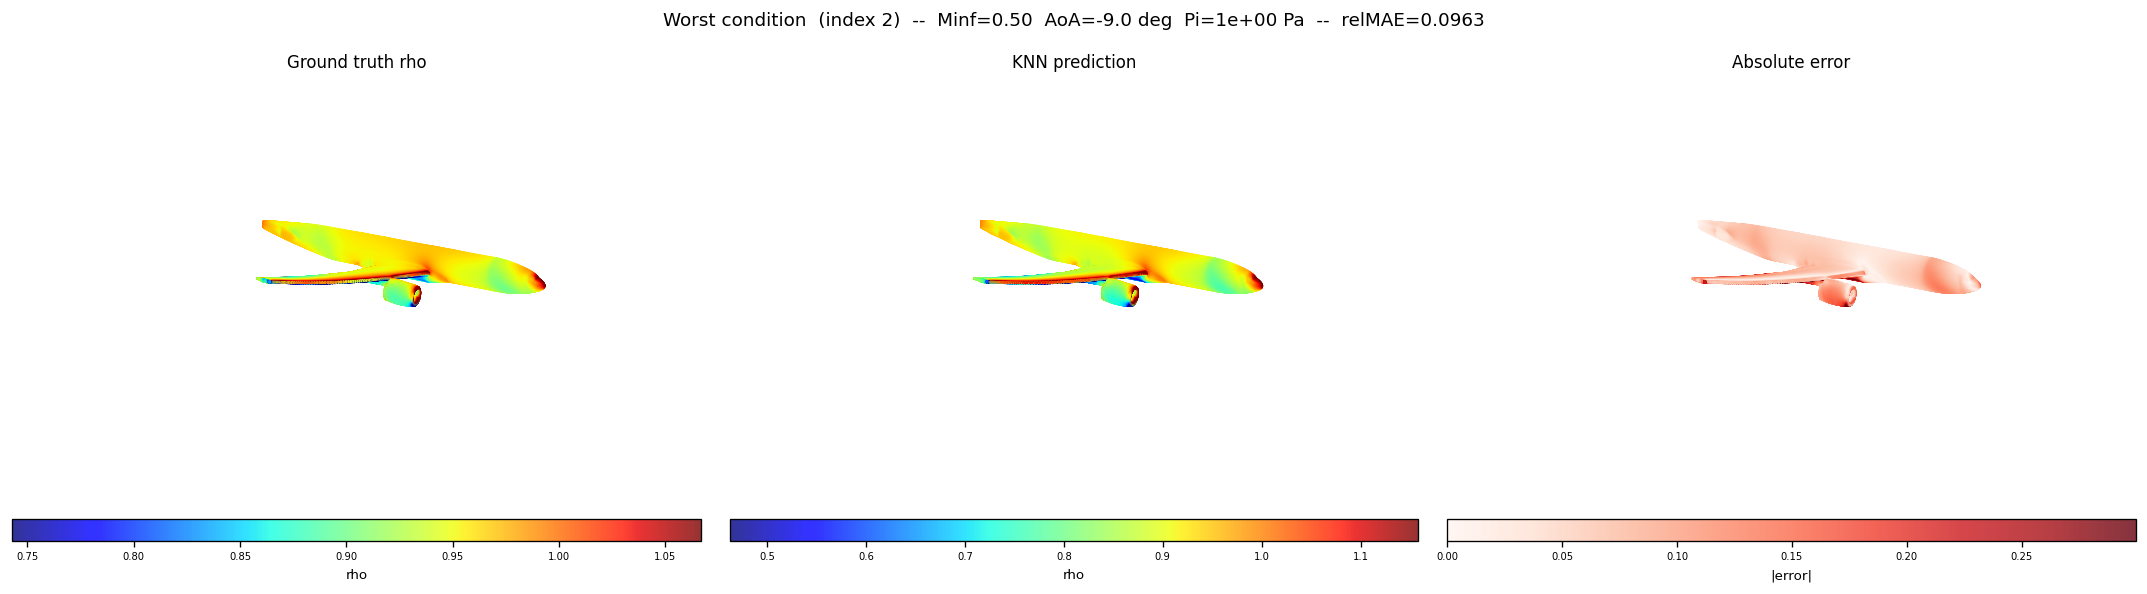

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

mach_labels = [r['mach'] for r in fold_results]
x_pos       = np.arange(len(fold_results))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)
fig.suptitle('Leave-two-consecutive-Machs-out cross-validation — per-fold metrics', fontsize=12)

metrics_cfg = [
    (R2_vals,    R2_mean,    R2_ci,    'steelblue',  'R²'),
    (wrMAE_vals, wrMAE_mean, wrMAE_ci, 'tomato',     'wrMAE'),
    (score_vals, score_mean, score_ci, 'seagreen',   'score (max=10)'),
]

for ax, (vals, mean, ci, color, ylabel) in zip(axes, metrics_cfg):
    ax.bar(x_pos, vals, color=color, width=0.6, yerr=ci, capsize=4, error_kw={'elinewidth': 1})
    ax.set_xticks(x_pos)
    ax.set_xticklabels(mach_labels, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Validation Mach pair', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel, fontsize=10)

plt.tight_layout()
plt.show()

def plot_condition(iworst, X_test, y_test, y_pred, nwallp, wrMAE):
    X_worst    = X_test [iworst * nwallp:(iworst + 1) * nwallp]
    y_worst    = y_test [iworst * nwallp:(iworst + 1) * nwallp]
    yhat_worst = y_pred [iworst * nwallp:(iworst + 1) * nwallp]

    Minf = X_worst[0, 6]
    AoA  = X_worst[0, 7]
    Pi   = X_worst[0, 8]

    X_coord = X_worst[:, 0]
    Y_coord = X_worst[:, 1]
    Z_coord = X_worst[:, 2]

    error = np.abs(y_worst - yhat_worst)

    def defminmaxscale(field):
        f03 = np.percentile(field, 3.)
        f50 = np.percentile(field, 50.)
        f97 = np.percentile(field, 97.)
        slopem = (f50 - f03) / 0.47
        slopep = (f97 - f50) / 0.47
        return max(0., f50 - 0.6 * slopem), f50 + 0.6 * slopep

    idx    = np.arange(0, nwallp)
    fields = [y_worst, yhat_worst, error]
    titles = ['Ground truth rho', 'KNN prediction', 'Absolute error']
    cmaps  = ['jet', 'jet', 'Reds']

    fig = plt.figure(figsize=(18, 5), dpi=120)
    fig.suptitle(
        f'Worst condition  (index {iworst})  --  '
        f'Minf={Minf:.2f}  AoA={AoA:.1f} deg  Pi={Pi:.0e} Pa  --  relMAE={wrMAE:.4f}',
        fontsize=11
    )

    for col, (field, title, cmap) in enumerate(zip(fields, titles, cmaps)):
        gs  = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[20, 1])
        ax  = fig.add_subplot(gs[0, col], projection='3d')

        fmin, fmax = defminmaxscale(field)
        sca = ax.scatter3D(
            X_coord[idx], Y_coord[idx], Z_coord[idx],
            c=field[idx], vmin=fmin, vmax=fmax,
            cmap=cmap, s=0.3, alpha=0.8
        )
        ax.view_init(elev=20, azim=120)
        ax.set_xlim(X_coord.min() - 5.0, X_coord.max() + 5.0)
        ax.set_ylim(Y_coord.min() - 5.0, Y_coord.max() + 5.0)
        ax.set_zlim(Z_coord.min(), Z_coord.max())
        lims = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
        ax.set_box_aspect(np.ptp(lims, axis=1), zoom=1.)
        ax.set_axis_off()
        ax.set_title(title, fontsize=10)

        cax  = fig.add_subplot(gs[1, col])
        cbar = fig.colorbar(sca, cax=cax, orientation='horizontal')
        cbar.set_label('rho' if col < 2 else '|error|', size=8)
        cbar.ax.tick_params(labelsize=6)

    plt.tight_layout()
    plt.show()


plot_condition(
    iworst    = iworst_global,
    X_test    = X_train,
    y_test    = y_train,
    y_pred    = y_cv_pred,
    nwallp    = nwallp,
    wrMAE     = wrMAE_global,
)

---
## 7. Preparing the submission


The cells below generate a submission zip file.
The manual way to construct one is:
Create a folder `submission/` containing:
- (Required) `model.py` your model class, **you have to name it `model.py`**
- (Optional) `python_packages` install the packages that are not available on Codabench by following the tutorial in `using_extra_packages/`

Then zip the content of the submission folder and upload to Codabench.
Be careful, make sure your zip doesn't contain a folder at the root, make sure it contains directly the `model.py` file.

In [8]:
import os
os.makedirs('submission', exist_ok=True)


In [9]:
%%writefile submission/model.py
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

COL_MINF, COL_AOA, COL_PI = 6, 7, 8

class Model:

    def __init__(self):
        self.knn    = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
        self.scaler = StandardScaler()
        self.nwallp = None

    def fit(self, X, y):
        cond0 = X[0, COL_MINF:COL_PI+1]
        self.nwallp = int(np.argmax(np.any(X[:, COL_MINF:COL_PI+1] != cond0, axis=1)))
        n_train = X.shape[0] // self.nwallp

        train_conds = X[::self.nwallp, COL_MINF:COL_PI+1]
        train_conds_scaled = self.scaler.fit_transform(train_conds)

        y_per_sim = y.reshape(n_train, self.nwallp)
        self.knn.fit(train_conds_scaled, y_per_sim)

    def predict(self, X):
        n_test = X.shape[0] // self.nwallp
        test_conds = X[::self.nwallp, COL_MINF:COL_PI+1]
        test_conds_scaled = self.scaler.transform(test_conds)
        y_pred = self.knn.predict(test_conds_scaled)
        return y_pred.reshape(-1)

Overwriting submission/model.py


In [10]:
import zipfile

with zipfile.ZipFile('submission.zip', 'w') as zf:
    zf.write('submission/model.py', arcname='model.py')

print('submission.zip created')

submission.zip created


In [11]:
import json

COMP_DIR = '../../output/'

component_labels = np.load(COMP_DIR + 'component_labels_unique.npy')   # (260774,)
nn_distances     = np.load(COMP_DIR + 'component_nn_distances.npy')

with open(COMP_DIR + 'component_map.json') as f:
    component_map = json.load(f)

# {name: boolean mask of shape (260774,)}
comp_masks = {name: (component_labels == int(idx)) for idx, name in component_map.items()}

print(f'Max NN distance : {nn_distances.max():.2e}  (sanity check, should be ~0)')
print()
for name, mask in comp_masks.items():
    print(f'{name:>10}  {mask.sum():>7d} points  ({100*mask.sum()/nwallp:.1f}%)')
print(f'{"total":>10}  {sum(m.sum() for m in comp_masks.values()):>7d} / {nwallp}')

Max NN distance : 2.67e-01  (sanity check, should be ~0)

  fuselage    64839 points  (24.9%)
   nacelle    56363 points  (21.6%)
     pylon    37208 points  (14.3%)
      wing   102364 points  (39.3%)
     total   260774 / 260774


In [12]:
import scipy.stats as stats

rng         = np.random.default_rng(42)
VAL_FRAC    = 0.2
N_BOOTSTRAP = 500

print('Per-component evaluation  (random 80/20 point-level split per component, seed=42)')
print(f'{"Component":>10}  {"n_train_pts":>12}  {"n_val_pts":>10}  {"R2":>8}  {"95% CI R2":>18}  {"wrMAE":>8}  {"rRMSE":>8}  {"nRMSE":>8}')
print('-' * 100)

comp_results = {}

for comp_name, point_mask in comp_masks.items():

    comp_indices = np.flatnonzero(point_mask)   # absolute indices in [0..260773]
    n_comp       = len(comp_indices)

    # Random point-level split
    perm             = rng.permutation(n_comp)
    n_val_pts        = max(1, int(round(n_comp * VAL_FRAC)))
    val_local_idx    = perm[:n_val_pts]    # indices into comp_indices
    train_local_idx  = perm[n_val_pts:]

    val_pts_idx   = comp_indices[val_local_idx]    # absolute point indices
    train_pts_idx = comp_indices[train_local_idx]

    # y_all shape: (n_train_sims, nwallp)
    # For each split take all simulations, restrict to the point subset
    y_train_pts = y_all[:, train_pts_idx]   # (n_sims, n_train_pts)
    y_val_pts   = y_all[:, val_pts_idx]     # (n_sims, n_val_pts)

    # Condition features: same for all points within a sim
    # We fit KNN on condition space (Minf, AoA, Pi) predicting the full point field
    # then evaluate only on the val points
    scaler_c     = StandardScaler()
    X_train_sc   = scaler_c.fit_transform(train_conds)   # (n_sims, 3)

    knn_c = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
    knn_c.fit(X_train_sc, y_train_pts)                   # predict train points
    y_pred_val = knn_c.predict(X_train_sc)               # (n_sims, n_train_pts) — in-sample

    # Re-fit to predict val points
    knn_val = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
    knn_val.fit(X_train_sc, y_val_pts)
    y_pred_val_pts = knn_val.predict(X_train_sc)         # (n_sims, n_val_pts)

    # Flatten across all sims
    y_val_flat  = y_val_pts.reshape(-1)
    y_pred_flat = y_pred_val_pts.reshape(-1)

    weights_pw  = np.repeat(train_weights, n_val_pts)    # (n_sims * n_val_pts,)

    c_R2    = compute_R2(y_val_flat, y_pred_flat, weights_pw)
    c_rRMSE = compute_rRMSE(y_val_flat, y_pred_flat)
    c_nRMSE = compute_nRMSE(y_val_flat, y_pred_flat)

    # wrMAE per simulation on val points
    relMAE_list = []
    for s in range(n_train):
        if train_weights[s] < 1.0:
            continue
        yc    = y_val_pts[s]
        yhatc = y_pred_val_pts[s]
        relMAE_list.append(np.mean(np.abs(yc - yhatc)) / np.mean(np.abs(yc)))
    c_wrMAE = float(np.max(relMAE_list)) if relMAE_list else float('nan')
    c_score = 5.0 * c_R2 + 5.0 * (1.0 - c_wrMAE)

    # Bootstrap 95% CI on R2 across simulations
    rng_boot = np.random.default_rng(0)
    boot_R2s = []
    for _ in range(N_BOOTSTRAP):
        bidx   = rng_boot.integers(0, n_train, size=n_train)
        y_b    = y_val_pts[bidx].reshape(-1)
        yhat_b = y_pred_val_pts[bidx].reshape(-1)
        w_b    = np.repeat(train_weights[bidx], n_val_pts)
        boot_R2s.append(compute_R2(y_b, yhat_b, w_b))
    boot_R2s   = np.array(boot_R2s)
    r2_ci_low  = float(np.percentile(boot_R2s, 2.5))
    r2_ci_high = float(np.percentile(boot_R2s, 97.5))

    comp_results[comp_name] = {
        'R2': c_R2, 'R2_ci': (r2_ci_low, r2_ci_high),
        'wrMAE': c_wrMAE, 'rRMSE': c_rRMSE, 'nRMSE': c_nRMSE, 'score': c_score,
        'val_pts_idx': val_pts_idx, 'train_pts_idx': train_pts_idx,
    }

    print(f'{comp_name:>10}  {len(train_pts_idx):>12}  {len(val_pts_idx):>10}  {c_R2:>8.4f}  [{r2_ci_low:+.4f}, {r2_ci_high:+.4f}]  {c_wrMAE:>8.4f}  {c_rRMSE:>8.4f}  {c_nRMSE:>8.4f}')

Per-component evaluation  (random 80/20 point-level split per component, seed=42)
 Component   n_train_pts   n_val_pts        R2           95% CI R2     wrMAE     rRMSE     nRMSE
----------------------------------------------------------------------------------------------------
  fuselage         51871       12968    0.9866  [+0.9849, +0.9881]    0.0209    0.0107    0.0086
   nacelle         45090       11273    0.9943  [+0.9937, +0.9949]    0.0290    0.0162    0.0091
     pylon         29766        7442    0.9734  [+0.9668, +0.9786]    0.1481    0.0248    0.0152
      wing         81891       20473    0.9672  [+0.9648, +0.9696]    0.0606    0.0360    0.0062


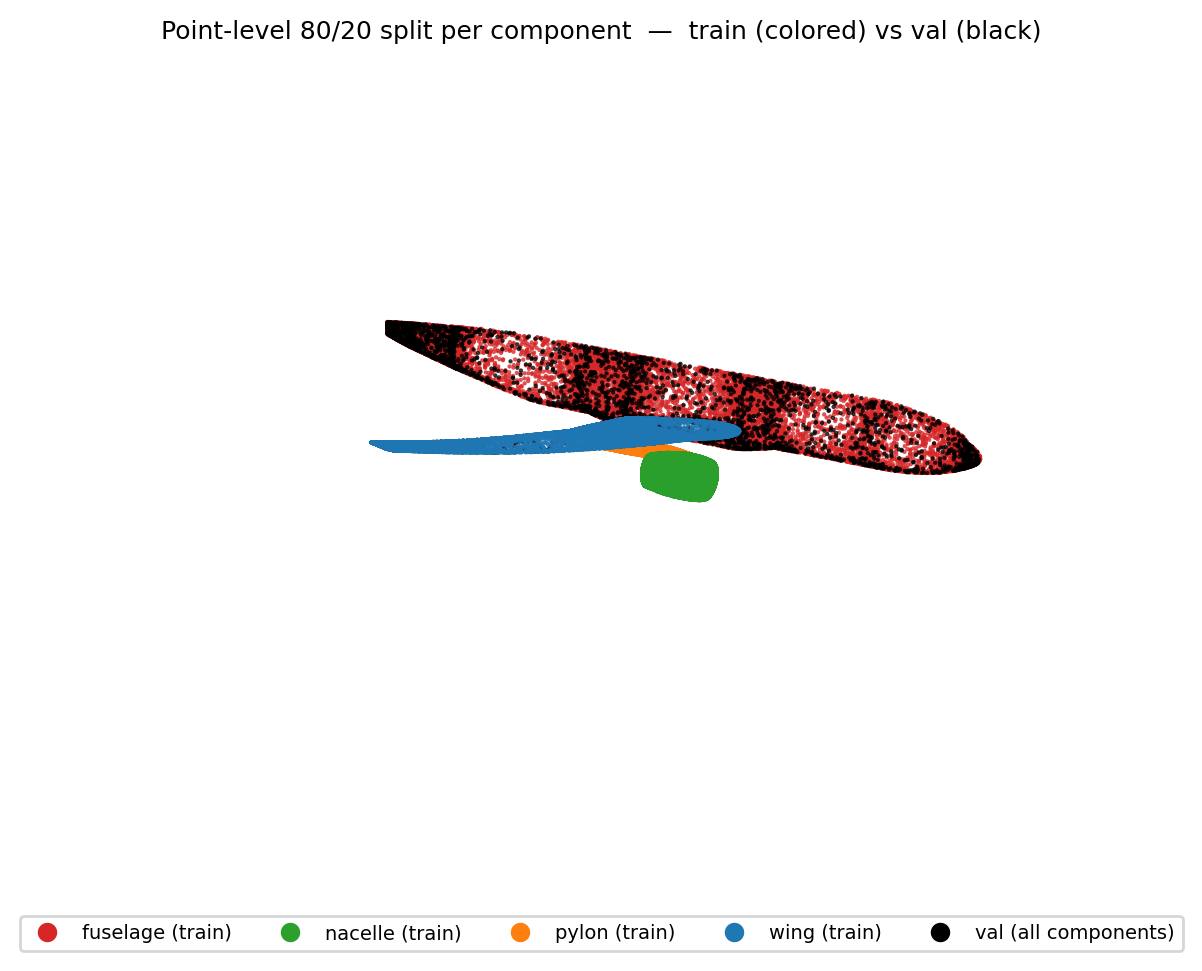

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

mesh_xyz = X_train[:nwallp, :3]
X_coord  = mesh_xyz[:, 0]
Y_coord  = mesh_xyz[:, 1]
Z_coord  = mesh_xyz[:, 2]

comp_colors = {
    'fuselage': '#d62728',
    'nacelle':  '#2ca02c',
    'pylon':    '#ff7f0e',
    'wing':     '#1f77b4',
}

cameraSettings = {
    'elevation':  20.,
    'azimuth':   120.,
    'zoom':        0.6,
    'xoffsets': [ 10., -14.],
    'yoffsets': [  0.,   0.],
    'zoffsets': [  0.,   0.],
}

subsample = 4
xmin, xmax = X_coord.min(), X_coord.max()
ymin, ymax = Y_coord.min(), Y_coord.max()
zmin, zmax = Z_coord.min(), Z_coord.max()

fig = plt.figure(dpi=200)
gs  = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[20, 1])
ax  = fig.add_subplot(gs[0], projection=Axes3D.name)

# Train points: colored by component
for comp_name, mask in comp_masks.items():
    idx = comp_results[comp_name]['train_pts_idx'][::subsample]
    ax.scatter3D(X_coord[idx], Y_coord[idx], Z_coord[idx],
                 c=comp_colors[comp_name], s=0.3, alpha=0.8)

# Val points: all black on top
for comp_name in comp_masks:
    idx = comp_results[comp_name]['val_pts_idx'][::subsample]
    ax.scatter3D(X_coord[idx], Y_coord[idx], Z_coord[idx],
                 c='black', s=0.3, alpha=0.8)

ax.view_init(elev=cameraSettings['elevation'], azim=cameraSettings['azimuth'])
ax.set(
    xlim=(xmin + cameraSettings['xoffsets'][0], xmax + cameraSettings['xoffsets'][1]),
    ylim=(ymin + cameraSettings['yoffsets'][0], ymax + cameraSettings['yoffsets'][1]),
    zlim=(zmin + cameraSettings['zoffsets'][0], zmax + cameraSettings['zoffsets'][1]),
)
ax.set_axis_off()
limits = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
ax.set_box_aspect(np.ptp(limits, axis=1), zoom=cameraSettings['zoom'])
fig.subplots_adjust(left=0, right=1, bottom=0.08, top=0.95)

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=comp_colors[n], markersize=8, label=f'{n} (train)')
    for n in comp_colors
] + [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='black', markersize=8, label='val (all components)')
]
fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=7, bbox_to_anchor=(0.5, 0.0))
fig.suptitle('Point-level 80/20 split per component  —  train (colored) vs val (black)',
             fontsize=9)
fig.tight_layout(pad=0.)
plt.show()

In [14]:
aoa_values, aoa_counts = np.unique(train_conds[:, 1], return_counts=True)
print(f'{"AoA":>8}  {"n_sims":>8}  {"note"}')
print('-' * 40)
for aoa, cnt in zip(aoa_values, aoa_counts):
    note = '*** CRITICAL (transonic separation)' if 3.0 <= abs(aoa) <= 5.0 else ''
    print(f'{aoa:>8.1f}  {cnt:>8}  {note}')

     AoA    n_sims  note
----------------------------------------
   -15.0         3  
   -12.5         6  
   -12.0         3  
   -10.0        12  
    -9.0        12  
    -8.0         3  
    -7.5        12  
    -7.0         9  
    -6.0         6  
    -5.0        21  *** CRITICAL (transonic separation)
    -4.0         3  *** CRITICAL (transonic separation)
    -3.0        12  *** CRITICAL (transonic separation)
    -2.5        12  
    -2.0         3  
    -1.5         9  
     0.0        27  
     1.0         3  
     1.5        15  
     2.0         9  
     2.5         3  
     3.0        18  *** CRITICAL (transonic separation)
     4.0        18  *** CRITICAL (transonic separation)
     4.5         6  *** CRITICAL (transonic separation)
     5.0        15  *** CRITICAL (transonic separation)
     6.0        15  
     7.0         9  
     7.5         9  
     8.0         9  
     9.0        15  
    10.0         9  
    10.5         6  
    12.0         6  
    12.5         

In [15]:
# Geometry split: fixed 80/20 per component (same as before)
rng_geo  = np.random.default_rng(42)
VAL_FRAC = 0.2
geo_splits = {}
for comp_name, point_mask in comp_masks.items():
    comp_indices  = np.flatnonzero(point_mask)
    n_comp        = len(comp_indices)
    perm          = rng_geo.permutation(n_comp)
    n_val         = max(1, int(round(n_comp * VAL_FRAC)))
    geo_splits[comp_name] = {
        'val_pts_idx':   comp_indices[perm[:n_val]],
        'train_pts_idx': comp_indices[perm[n_val:]],
    }
    print(f'{comp_name:>10}  train_pts={len(geo_splits[comp_name]["train_pts_idx"]):>7}  '
          f'val_pts={len(geo_splits[comp_name]["val_pts_idx"]):>7}')
    
# Condition split: hold out AoA = {-2, 0, 2} as test
# These are moderate angles — well-behaved, not in the critical 3-5 deg region
# but still different enough to test generalisation
AOA_TEST  = {-2.0, 0.0, 2.0}
AOA_TRAIN = set(aoa_values.tolist()) - AOA_TEST

train_sim_mask = np.array([
    float(round(train_conds[s, 1], 1)) not in AOA_TEST
    for s in range(n_train)
])
test_sim_mask = ~train_sim_mask

train_sim_idx = np.where(train_sim_mask)[0]
test_sim_idx  = np.where(test_sim_mask)[0]

print(f'\nCondition split on AoA')
print(f'  Train AoA : {sorted(AOA_TRAIN)}  ({train_sim_mask.sum()} sims)')
print(f'  Test  AoA : {sorted(AOA_TEST)}   ({test_sim_mask.sum()} sims)')

  fuselage  train_pts=  51871  val_pts=  12968
   nacelle  train_pts=  45090  val_pts=  11273
     pylon  train_pts=  29766  val_pts=   7442
      wing  train_pts=  81891  val_pts=  20473

Condition split on AoA
  Train AoA : [-15.0, -12.5, -12.0, -10.0, -9.0, -8.0, -7.5, -7.0, -6.0, -5.0, -4.0, -3.0, -2.5, -1.5, 1.0, 1.5, 2.5, 3.0, 4.0, 4.5, 5.0, 6.0, 7.0, 7.5, 8.0, 9.0, 10.0, 10.5, 12.0, 12.5, 15.0]  (285 sims)
  Test  AoA : [-2.0, 0.0, 2.0]   (39 sims)


In [16]:
mesh_xyz    = X_train[:nwallp, :3]    # (260774, 3)
mesh_normals = X_train[:nwallp, 3:6]  # (260774, 3)
mesh_geom   = np.concatenate([mesh_xyz, mesh_normals], axis=1)  # (260774, 6)

def build_pointwise_X(sim_indices, geom_pts_idx):
    """
    For each sim in sim_indices, repeat its (Minf, AoA, Pi) for each point in geom_pts_idx.
    Returns X of shape (n_sims * n_pts, 9) and y of shape (n_sims * n_pts,).
    """
    n_sims_local = len(sim_indices)
    n_pts        = len(geom_pts_idx)
    geom_block   = mesh_geom[geom_pts_idx]              # (n_pts, 6)

    X_list, y_list = [], []
    for s in sim_indices:
        cond = train_conds[s]                            # (3,)
        cond_repeated = np.tile(cond, (n_pts, 1))        # (n_pts, 3)
        X_list.append(np.concatenate([geom_block, cond_repeated], axis=1))
        y_list.append(y_all[s, geom_pts_idx])
    return np.vstack(X_list), np.concatenate(y_list)

print('build_pointwise_X defined')
print(f'Feature vector per point: (x, y, z, nx, ny, nz, Minf, AoA, Pi) = 9 dims')

build_pointwise_X defined
Feature vector per point: (x, y, z, nx, ny, nz, Minf, AoA, Pi) = 9 dims


In [ ]:
import scipy.stats as stats

N_BOOTSTRAP = 200

print('Per-component  |  geo split 80/20  +  condition split (AoA test={-2,0,2})')
print(f'{"Component":>10}  {"R2":>8}  {"95% CI R2":>18}  {"wrMAE":>8}  {"rRMSE":>8}  {"nRMSE":>8}  {"score":>8}')
print('-' * 90)

full_results = {}

for comp_name in comp_masks:
    train_pts_idx = geo_splits[comp_name]['train_pts_idx']
    val_pts_idx   = geo_splits[comp_name]['val_pts_idx']

    # Build train set: train sims × train geometry points
    X_fit, y_fit = build_pointwise_X(train_sim_idx, train_pts_idx)

    # Scale
    scaler_full = StandardScaler()
    X_fit_sc    = scaler_full.fit_transform(X_fit)

    # Fit pointwise KNN
    knn_full = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
    knn_full.fit(X_fit_sc, y_fit)

    # Evaluate on: test sims × val geometry points
    X_eval, y_eval = build_pointwise_X(test_sim_idx, val_pts_idx)
    X_eval_sc      = scaler_full.transform(X_eval)
    y_pred_eval    = knn_full.predict(X_eval_sc)

    n_val_pts    = len(val_pts_idx)
    n_test_sims  = len(test_sim_idx)
    weights_pw   = np.repeat(train_weights[test_sim_idx], n_val_pts)

    c_R2    = compute_R2(y_eval, y_pred_eval, weights_pw)
    c_rRMSE = compute_rRMSE(y_eval, y_pred_eval)
    c_nRMSE = compute_nRMSE(y_eval, y_pred_eval)

    # wrMAE per test simulation
    relMAE_list = []
    for local_s, s in enumerate(test_sim_idx):
        if train_weights[s] < 1.0:
            continue
        start = local_s * n_val_pts
        end   = start + n_val_pts
        yc    = y_eval      [start:end]
        yhatc = y_pred_eval [start:end]
        relMAE_list.append(np.mean(np.abs(yc - yhatc)) / np.mean(np.abs(yc)))
    c_wrMAE = float(np.max(relMAE_list)) if relMAE_list else float('nan')
    c_score = 5.0 * c_R2 + 5.0 * (1.0 - c_wrMAE)

    # Bootstrap CI on R2 — resample over test simulations
    rng_boot = np.random.default_rng(0)
    y_eval_sims    = y_eval.reshape(n_test_sims, n_val_pts)
    y_pred_sims    = y_pred_eval.reshape(n_test_sims, n_val_pts)
    boot_R2s = []
    for _ in range(N_BOOTSTRAP):
        bidx   = rng_boot.integers(0, n_test_sims, size=n_test_sims)
        y_b    = y_eval_sims[bidx].reshape(-1)
        yhat_b = y_pred_sims[bidx].reshape(-1)
        w_b    = np.repeat(train_weights[test_sim_idx[bidx]], n_val_pts)
        boot_R2s.append(compute_R2(y_b, yhat_b, w_b))
    boot_R2s   = np.array(boot_R2s)
    r2_ci_low  = float(np.percentile(boot_R2s, 2.5))
    r2_ci_high = float(np.percentile(boot_R2s, 97.5))

    full_results[comp_name] = {
        'R2': c_R2, 'R2_ci': (r2_ci_low, r2_ci_high),
        'wrMAE': c_wrMAE, 'rRMSE': c_rRMSE, 'nRMSE': c_nRMSE, 'score': c_score,
        'knn': knn_full, 'scaler': scaler_full,
        'val_pts_idx': val_pts_idx, 'train_pts_idx': train_pts_idx,
    }

    print(f'{comp_name:>10}  {c_R2:>8.4f}  [{r2_ci_low:+.4f}, {r2_ci_high:+.4f}]  '
          f'{c_wrMAE:>8.4f}  {c_rRMSE:>8.4f}  {c_nRMSE:>8.4f}  {c_score:>8.4f}')

Per-component  |  geo split 80/20  +  condition split (AoA test={-2,0,2})
 Component        R2           95% CI R2     wrMAE     rRMSE     nRMSE     score
------------------------------------------------------------------------------------------
  fuselage    0.9731  [+0.9644, +0.9792]    0.0154    0.0139    0.0126    9.7882
